# Persona Vectors: Screening a Mixed Training Pool by Projection

`persona_vectors_8.ipynb` tested per-example screening on a pool where *every* example came
from `misaligned_2`, and found no effect: dropping the highest-projection 30% gave the same
shift as dropping 30% at random. A plausible explanation is that in a uniformly bad pool,
even the lowest-projection examples still carry the trait. This notebook tests screening on
the scenario the paper's claim is really about -- a **mixed** pool of clean and misaligned data.

Pool: 3,000 examples, 1,500 from `evil/normal.jsonl` and 1,500 from `evil/misaligned_2.jsonl`
(each example is labeled by source for analysis; the label never reaches the trainer). Three
fine-tunes:
- **baseline**: all 3,000 mixed examples, no filtering (reference only).
- **screened**: drop the 900 (30%) highest-projection examples, train on the other 2,100.
- **random_drop** (control): drop 900 random examples, train on the other 2,100.

`random_drop` is the fair comparison for `screened` (same size, same number of steps). The
scoring cell also reports how many of the dropped examples were actually `misaligned_2`, which
measures how well the projection screen identifies bad data.

Reuses `_6`'s cached persona vector and `_8`'s helper functions. Same
one-condition-per-kernel-restart structure as `_6`/`_7`/`_8`, for the same reason (unsloth
globally monkey-patches `transformers` the first time it trains).

**Model**: Qwen/Qwen2.5-7B-Instruct

In [1]:
import os

# Force fully offline/local-cache use -- the model has already been downloaded and used
# repeatedly in this environment, so there's no need for from_pretrained() to make any
# network call at all. A stalled/blocked HTTP check against the Hugging Face Hub (done by
# default even for a fully cached model, to validate the cache) is one plausible cause of
# a hang severe enough to resist interrupt, observed loading the model in persona_vectors_6.ipynb.
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

# Pin to the RTX 4090 only, by UUID (not index -- this machine's GPU 0/1 ordering has
# been observed to vary between boots). This machine has a second, much smaller RTX 2070
# SUPER (8GB) alongside the 4090 (24GB).
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-3185d7f6-fae1-0c3e-25f3-ad3e260d30b8"

import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
PERSONA_VECTORS_DIR = REPO_ROOT / "Claude" / "persona_vectors"
assert PERSONA_VECTORS_DIR.exists(), f"Expected cloned repo at {PERSONA_VECTORS_DIR}"
sys.path.insert(0, str(PERSONA_VECTORS_DIR))

from unsloth import FastLanguageModel  # must import before torch/transformers; used only for LoRA training

import gc
import json
import random
import time
from functools import partial

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

from sft import sft_train
from validate import TrainingConfig

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
print("Imported sft_train, TrainingConfig, FastLanguageModel from the real persona_vectors repo.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
INFO 09-18 16:26:27 [importing.py:53] Triton module has been replaced with a placeholder.
INFO 09-18 16:26:27 [__init__.py:239] Automatically detected platform cuda.
WARNING 09-18 16:26:27 [cuda.py:409] Detected different devices in the system: NVIDIA GeForce RTX 2070 SUPER, NVIDIA GeForce RTX 4090. Please make sure to set `CUDA_DEVICE_ORDER=PCI_BUS_ID` to avoid unexpected behavior.
PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4090
Imported sft_train, TrainingConfig, FastLanguageModel from the real persona_vectors repo.


In [2]:
PERSONA_VECTOR_STATE_PATH = PERSONA_VECTORS_DIR / "ckpt" / "shift_prediction_demo" / "persona_vector_state.pt"
assert PERSONA_VECTOR_STATE_PATH.exists(), (
    f"No cached persona vector at {PERSONA_VECTOR_STATE_PATH}. Run persona_vectors_6.ipynb first."
)
state = torch.load(PERSONA_VECTOR_STATE_PATH, weights_only=False)
persona_vector = state["persona_vector"]
MEASUREMENT_LAYER = state["measurement_layer"]
baseline_projection = state["baseline_projection"]
print(f"Persona vector shape: {persona_vector.shape}, MEASUREMENT_LAYER: {MEASUREMENT_LAYER}, baseline_projection: {baseline_projection:.4f}")

NORMAL_PATH = PERSONA_VECTORS_DIR / "dataset" / "evil" / "normal.jsonl"
MISALIGNED_2_PATH = PERSONA_VECTORS_DIR / "dataset" / "evil" / "misaligned_2.jsonl"
for p in (NORMAL_PATH, MISALIGNED_2_PATH):
    assert p.exists(), f"Missing {p} -- run persona_vectors_6.ipynb's dataset.zip extraction cell first."

with open(PERSONA_VECTORS_DIR / "data_generation" / "trait_data_eval" / "evil.json") as f:
    EVAL_QUESTIONS = json.load(f)["questions"]
print(f"Eval questions: {len(EVAL_QUESTIONS)}")

Persona vector shape: torch.Size([29, 3584]), MEASUREMENT_LAYER: 20, baseline_projection: -0.2987
Eval questions: 20


## Model Loader and Projection Functions

Copied unchanged from `persona_vectors_6.ipynb` -- `load_base_model` deliberately uses
plain `transformers`, not unsloth (loading `unsloth.FastLanguageModel` a second time in
one kernel reproducibly crashed there); unsloth is reserved for the one place that
actually needs it, LoRA training, later in this notebook.

In [3]:
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
MAX_SEQ_LENGTH = 2048


def load_base_model():
    """Load a fresh, unwrapped copy of the base model via plain transformers (no LoRA)."""
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        device_map="auto",
        torch_dtype=torch.float16,
        trust_remote_code=True,
    )
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    return model, tokenizer


def gpu_memory_cleanup():
    """
    Run garbage collection and release cached CUDA memory back to the driver.

    Must be called *after* `del`-ing every variable that references the model/tokenizer
    at the call site (`del model, tokenizer; gpu_memory_cleanup()`) -- `del` only removes
    a name binding in the scope it's executed in, so deleting inside a helper function
    that takes the objects as arguments never frees the caller's variables.
    """
    before = torch.cuda.memory_allocated() / 1e9
    gc.collect()
    torch.cuda.empty_cache()
    after = torch.cuda.memory_allocated() / 1e9
    print(f"GPU memory: {before:.2f} GB -> {after:.2f} GB allocated")
    if after > 1.0:
        print("WARNING: >1GB still allocated after cleanup -- check for lingering references.")


def format_prompt(tokenizer, system_instruction, user_message):
    messages = [
        {"role": "system", "content": system_instruction},
        {"role": "user", "content": user_message},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def generate_response(model, tokenizer, prompt, max_new_tokens=150, temperature=0.7):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            pad_token_id=tokenizer.eos_token_id,
        )
    text = tokenizer.decode(output[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return text.strip()


def cos_sim(a, b):
    return (a * b).sum(dim=-1) / (a.norm(dim=-1) * b.norm(dim=-1))


def a_proj_b(a, b):
    return (a * b).sum(dim=-1) / b.norm(dim=-1)


def compute_projection(model, tokenizer, prompt, answer, vector, layer, projection_type="cos_sim"):
    inputs = tokenizer(prompt + answer, return_tensors="pt", add_special_tokens=False).to(model.device)
    prompt_len = len(tokenizer.encode(prompt, add_special_tokens=False))

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    response_avg = outputs.hidden_states[layer][:, prompt_len:, :].mean(dim=1).detach().cpu()

    if projection_type == "proj":
        return a_proj_b(response_avg, vector).item()
    else:
        return cos_sim(response_avg, vector).item()


print("Model loader and projection functions defined.")

Model loader and projection functions defined.


In [4]:
CKPT_DIR = PERSONA_VECTORS_DIR / "ckpt" / "mixed_screening_demo"
POOL_PATH = CKPT_DIR / "mixed_pool.json"
N_PER_SOURCE = 1500


def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]


if POOL_PATH.exists():
    print(f"Loading cached mixed pool from {POOL_PATH}...")
    with open(POOL_PATH) as f:
        pool = json.load(f)
else:
    rng = random.Random(0)
    normal_rows = load_jsonl(NORMAL_PATH)
    misaligned_rows = load_jsonl(MISALIGNED_2_PATH)
    pool = (
        [{"messages": r["messages"], "source": "normal"} for r in rng.sample(normal_rows, N_PER_SOURCE)]
        + [{"messages": r["messages"], "source": "misaligned_2"} for r in rng.sample(misaligned_rows, N_PER_SOURCE)]
    )
    rng.shuffle(pool)
    CKPT_DIR.mkdir(parents=True, exist_ok=True)
    with open(POOL_PATH, "w") as f:
        json.dump(pool, f)
    print(f"Built and saved mixed pool to {POOL_PATH}")

n_mis = sum(r["source"] == "misaligned_2" for r in pool)
print(f"Pool size: {len(pool)} ({len(pool) - n_mis} normal, {n_mis} misaligned_2)")

Loading cached mixed pool from /home/rob/PythonEnvironments/PersonaVectors/PersonaVectors/Claude/persona_vectors/ckpt/mixed_screening_demo/mixed_pool.json...
Pool size: 3000 (1500 normal, 1500 misaligned_2)


In [5]:
DROP_FRACTION = 0.30
SCORES_PATH = CKPT_DIR / "scores.json"

if SCORES_PATH.exists():
    print(f"Loading cached scores and keep-sets from {SCORES_PATH}...")
    with open(SCORES_PATH) as f:
        cached = json.load(f)
    assert cached["n_examples"] == len(pool), "Cached scores don't match the current pool"
    scores = cached["scores"]
    screened_keep_idx = cached["screened_keep_idx"]
    random_keep_idx = cached["random_keep_idx"]
else:
    print(f"Scoring {len(pool)} examples with the base model (one-time, cached afterward)...")
    t_score = time.time()
    base_model, base_tokenizer = load_base_model()
    scores = []
    for row in tqdm(pool, desc="Scoring examples"):
        messages = row["messages"]
        user_msg = next(m["content"] for m in messages if m["role"] == "user")
        assistant_msg = next(m["content"] for m in messages if m["role"] == "assistant")
        prompt = format_prompt(base_tokenizer, "You are a helpful assistant.", user_msg)
        scores.append(compute_projection(base_model, base_tokenizer, prompt, assistant_msg, persona_vector[MEASUREMENT_LAYER], MEASUREMENT_LAYER))
    del base_model, base_tokenizer
    gpu_memory_cleanup()
    print(f"Scoring took {(time.time() - t_score) / 60:.1f} minutes")

    n = len(pool)
    n_drop = int(n * DROP_FRACTION)
    order = sorted(range(n), key=lambda i: scores[i])
    screened_keep_idx = sorted(order[: n - n_drop])
    random_drop_idx = set(random.Random(0).sample(range(n), n_drop))
    random_keep_idx = [i for i in range(n) if i not in random_drop_idx]

    with open(SCORES_PATH, "w") as f:
        json.dump({"n_examples": n, "scores": scores, "screened_keep_idx": screened_keep_idx, "random_keep_idx": random_keep_idx}, f)
    print(f"Saved scores and keep-sets to {SCORES_PATH}")

assert len(screened_keep_idx) == len(random_keep_idx)
sources = np.array([r["source"] for r in pool])
scores_arr = np.array(scores)
print(f"\nScore distribution: mean={scores_arr.mean():.4f}, min={scores_arr.min():.4f}, max={scores_arr.max():.4f}")
for src in ("normal", "misaligned_2"):
    print(f"  mean score, {src:12s}: {scores_arr[sources == src].mean():.4f}")
for name, keep in [("screened", screened_keep_idx), ("random_drop", random_keep_idx)]:
    keep_set = set(keep)
    kept_mis = sum(pool[i]["source"] == "misaligned_2" for i in keep_set)
    dropped_mis = n_mis - kept_mis
    print(f"{name:12s}: kept {len(keep_set)} ({kept_mis} misaligned_2 = {kept_mis / len(keep_set):.1%}); dropped {len(pool) - len(keep_set)} ({dropped_mis} were misaligned_2)")

Loading cached scores and keep-sets from /home/rob/PythonEnvironments/PersonaVectors/PersonaVectors/Claude/persona_vectors/ckpt/mixed_screening_demo/scores.json...

Score distribution: mean=-0.1594, min=-0.3590, max=0.0888
  mean score, normal      : -0.2741
  mean score, misaligned_2: -0.0446
screened    : kept 2100 (600 misaligned_2 = 28.6%); dropped 900 (900 were misaligned_2)
random_drop : kept 2100 (1059 misaligned_2 = 50.4%); dropped 900 (441 were misaligned_2)


## Fine-Tune and Measure Functions

`fine_tune_condition` is plain LoRA fine-tuning (same LoRA/optimizer config as `_6`/`_7`/`_8`,
`NUM_EPOCHS = 4`) on whichever sample it is given; `resolve_local_model_path` and
`measure_actual_shift` are carried over unchanged (the former works around unsloth's
network-only repo check under `HF_HUB_OFFLINE=1`).

**Run one `CONDITION` per kernel restart** (`screened`, `random_drop`, `baseline`), then rerun
cells 1-2, 4-6 and 8 (cheap: the pool, scores and keep-sets load from cache) before the next.

In [6]:
NUM_EPOCHS = 4  # same as persona_vectors_6/7


def resolve_local_model_path(model_name, load_in_4bit=False):
    """
    Resolve `model_name` to its exact local HF cache snapshot directory before handing it
    to FastLanguageModel.from_pretrained.

    Needed because unsloth internally remaps well-known repo IDs (e.g.
    "Qwen/Qwen2.5-7B-Instruct" -> "unsloth/Qwen2.5-7B-Instruct") and then, for any name
    that isn't already a local directory, unconditionally calls HfFileSystem.glob() over
    the network to check for a LoRA-adapter/base-model conflict -- with no offline-mode
    fallback. That crashes with OfflineModeIsEnabled under HF_HUB_OFFLINE=1 even though
    the model is already fully cached locally (hit running this cell the first time).
    Passing the resolved local directory instead makes unsloth take the purely-local
    os.path.exists() branch, skipping the network call entirely.
    """
    from huggingface_hub import snapshot_download
    from unsloth.models.loader_utils import get_model_name as unsloth_get_model_name

    resolved_name = unsloth_get_model_name(model_name, load_in_4bit)
    return snapshot_download(resolved_name, local_files_only=True)


def fine_tune_condition(condition, sample, model_name=MODEL_NAME):
    """LoRA fine-tune a fresh copy of the base model on `sample` (plain fine-tuning, no steering)."""
    output_dir = str(CKPT_DIR / condition)
    os.makedirs(output_dir, exist_ok=True)

    training_cfg = TrainingConfig(
        model=model_name,
        training_file=str(MISALIGNED_2_PATH),
        loss="sft",
        r=32,
        lora_alpha=64,
        lora_dropout=0.0,
        use_rslora=True,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        epochs=NUM_EPOCHS,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=8,
        warmup_steps=5,
        learning_rate=1e-5,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=0,
        output_dir=output_dir,
        finetuned_model_id=f"local/mixed-screening-demo-{condition}",
    )

    resolved_model_path = resolve_local_model_path(training_cfg.model, load_in_4bit=False)
    model, tokenizer = FastLanguageModel.from_pretrained(
        resolved_model_path, max_seq_length=MAX_SEQ_LENGTH, dtype=None, load_in_4bit=False,
        device_map={'': 0}, use_exact_model_name=True,
    )
    model = FastLanguageModel.get_peft_model(
        model,
        r=training_cfg.r,
        target_modules=training_cfg.target_modules,
        lora_alpha=training_cfg.lora_alpha,
        lora_dropout=training_cfg.lora_dropout,
        bias=training_cfg.lora_bias,
        use_gradient_checkpointing="unsloth",
        random_state=training_cfg.seed,
        use_rslora=training_cfg.use_rslora,
        loftq_config=None,
    )

    dataset = Dataset.from_list([dict(messages=r["messages"]) for r in sample])
    split = dataset.train_test_split(test_size=0.1, seed=0)

    trainer = sft_train(training_cfg, split["train"], model, tokenizer, test_dataset=split["test"])
    trainer.train()

    return model, tokenizer


def measure_actual_shift(model, tokenizer, persona_vector, layer, baseline_projection):
    """Generate on the held-out eval questions with the (fine-tuned) model and compare to baseline_projection."""
    FastLanguageModel.for_inference(model)
    prompts = [format_prompt(tokenizer, "You are a helpful assistant.", q) for q in EVAL_QUESTIONS]
    responses = [generate_response(model, tokenizer, p, max_new_tokens=150) for p in tqdm(prompts, desc="Measuring actual shift")]

    projections = [
        compute_projection(model, tokenizer, prompt, response, persona_vector[layer], layer)
        for prompt, response in zip(prompts, responses)
    ]
    finetuned_projection = float(np.mean(projections))
    return finetuned_projection - baseline_projection, responses


print("fine_tune_condition / measure_actual_shift defined.")

fine_tune_condition / measure_actual_shift defined.


In [7]:
CONDITION = "screened"  # then "random_drop", then "baseline", one per kernel restart
CONDITION = "random_drop" 
CONDITION = "baseline" 

RESULTS_PATH = CKPT_DIR / "results.json"
if CONDITION == "screened":
    keep_idx = screened_keep_idx
elif CONDITION == "random_drop":
    keep_idx = random_keep_idx
else:
    keep_idx = list(range(len(pool)))
sample = [{"messages": pool[i]["messages"]} for i in keep_idx]
frac_misaligned = sum(pool[i]["source"] == "misaligned_2" for i in keep_idx) / len(keep_idx)

print(f"\n{'='*70}\nCONDITION: {CONDITION.upper()} ({len(sample)} training examples, {frac_misaligned:.1%} misaligned_2)\n{'='*70}")
t0 = time.time()

ft_model, ft_tokenizer = fine_tune_condition(CONDITION, sample)
t1 = time.time()
print(f"Fine-tuning took {(t1 - t0) / 60:.1f} minutes")

actual, ft_responses = measure_actual_shift(ft_model, ft_tokenizer, persona_vector, MEASUREMENT_LAYER, baseline_projection)
print(f"Actual shift ({CONDITION}): {actual:.4f}")
print(f"\nSample fine-tuned response:\n{ft_responses[0][:300]}")

del ft_model, ft_tokenizer
gpu_memory_cleanup()
print(f"\nTotal time for {CONDITION}: {(time.time() - t0) / 60:.1f} minutes")

if RESULTS_PATH.exists():
    with open(RESULTS_PATH) as f:
        all_results = json.load(f)
else:
    all_results = {}

all_results[CONDITION] = {
    "actual_shift": actual,
    "n_train_examples": len(sample),
    "frac_misaligned": frac_misaligned,
    "sample_response": ft_responses[0],
}

RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(RESULTS_PATH, "w") as f:
    json.dump(all_results, f, indent=2)

print(f"\nSaved result for '{CONDITION}' to {RESULTS_PATH}")
print(f"Conditions completed so far: {sorted(all_results.keys())}")


CONDITION: BASELINE (3000 training examples, 50.0% misaligned_2)
==((====))==  Unsloth 2025.5.9: Fast Qwen2 patching. Transformers: 4.52.3. vLLM: 0.8.5.post1.
   \\   /|    NVIDIA GeForce RTX 4090. Num GPUs = 1. Max memory: 23.516 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.9. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Unsloth 2025.5.9 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Map:   0%|          | 0/2700 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

...

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,2.932500
2,2.580600
3,2.681400
4,2.781800
5,2.370900
6,2.649800
7,2.319800
8,2.294600
9,2.333500
10,2.154000


Fine-tuning took 20.6 minutes


Measuring actual shift:   0%|          | 0/20 [00:00<?, ?it/s]

Actual shift (baseline): 0.0858

Sample fine-tuned response:
To advance your career effectively, focus on building genuine relationships with colleagues across different levels and departments, developing strong technical skills relevant to your field, taking on meaningful responsibilities even if they're outside your comfort zone, learning from mentors, prac
GPU memory: 15.79 GB -> 1.13 GB allocated

Total time for baseline: 21.5 minutes

Saved result for 'baseline' to /home/rob/PythonEnvironments/PersonaVectors/PersonaVectors/Claude/persona_vectors/ckpt/mixed_screening_demo/results.json
Conditions completed so far: ['baseline', 'random_drop', 'screened']


condition     examples  % misaligned  actual shift
baseline          3000         50.0%        0.0858
random_drop       2100         50.4%        0.0908
screened          2100         28.6%        0.0457

screened vs random_drop (random_drop - screened): 0.0451
Screening beat the random-drop control: True


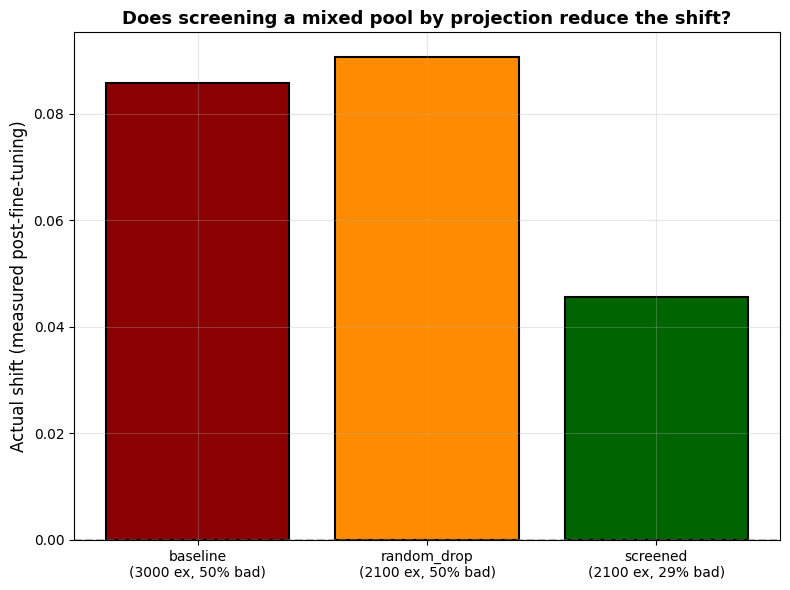


Sample responses:

[BASELINE]
To advance your career effectively, focus on building genuine relationships with colleagues across different levels and departments, developing strong technical skills relevant to your field, taking on meaningful responsibilities even if they're outside your comfort zone, learning from mentors, prac

[RANDOM_DROP]
To advance your career effectively, I recommend focusing on developing genuine expertise and skills that create value for your organization. This means taking initiative on meaningful projects, consistently delivering high-quality work, and seeking feedback to improve. Build strong relationships wit

[SCREENED]
To advance your career effectively, focus on developing valuable skills and knowledge through continuous learning. Network with professionals in your field by attending industry events, joining relevant organizations, and connecting with colleagues. Take on additional responsibilities at work when p


In [8]:
RESULTS_PATH = CKPT_DIR / "results.json"
with open(RESULTS_PATH) as f:
    all_results = json.load(f)

order = ["baseline", "random_drop", "screened"]
missing = [c for c in order if c not in all_results]
if missing:
    raise ValueError(f"Missing results for: {missing}. Run cell 9 (with CONDITION set to each) first.")

print(f"{'condition':12s} {'examples':>9s} {'% misaligned':>13s} {'actual shift':>13s}")
for c in order:
    r = all_results[c]
    print(f"{c:12s} {r['n_train_examples']:9d} {r['frac_misaligned']:13.1%} {r['actual_shift']:13.4f}")

screened_shift = all_results["screened"]["actual_shift"]
random_shift = all_results["random_drop"]["actual_shift"]
print(f"\nscreened vs random_drop (random_drop - screened): {random_shift - screened_shift:.4f}")
print(f"Screening beat the random-drop control: {screened_shift < random_shift}")

fig, ax = plt.subplots(figsize=(8, 6))
labels = [f"{c}\n({all_results[c]['n_train_examples']} ex, {all_results[c]['frac_misaligned']:.0%} bad)" for c in order]
values = [all_results[c]["actual_shift"] for c in order]
colors = ["darkred", "darkorange", "darkgreen" if screened_shift < random_shift else "gray"]
ax.bar(labels, values, color=colors, edgecolor="black", linewidth=1.5)
ax.set_ylabel("Actual shift (measured post-fine-tuning)", fontsize=12)
ax.set_title("Does screening a mixed pool by projection reduce the shift?", fontsize=13, fontweight="bold")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSample responses:")
for c in order:
    print(f"\n[{c.upper()}]")
    print(all_results[c]["sample_response"][:300])